# Optimalizace hyperparametrů – Cvičení 1 (Ceny diamantů)
Tento sešit je vypracovaným řešením cvičení **Hyperparameter optimization - exercise 1**.
Rozšiřuje model rozhodovacího stromu pro regresi vytvořený během 1. dne kurzu:
1. Načtení dat `diamonds.csv`, ověření hodnot a zakódování kategorií (`cut`, `color`, `clarity`) pomocí `LabelEncoder`.
2. Rozdělení dat na trénovací a testovací sadu v poměru 70/30 (`random_state=42`).
3. Pomocí třídy `GridSearchCV` nalezení optimální dvojice hyperparametrů: `max_depth` a `criterion`.
4. Úprava funkce `train_and_test_decision_tree(hyperparameters: dict)`, aby přijímala slovník hyperparametrů.
5. Natrénování modelu s optimálními parametry a ověření zlepšení metrik ($R^2$, RMSE, MAE) oproti modelu z 1. dne.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("Knihovny úspěšně importovány.")

Knihovny úspěšně importovány.


In [2]:
# Robustní nalezení cesty k souboru diamonds.csv
csv_candidates = [
    'data/diamonds.csv',
    '../01_Regression/data/diamonds.csv',
    '01_Regression/data/diamonds.csv',
    'diamonds.csv'
]
csv_path = None
for p in csv_candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Soubor diamonds.csv nebyl nalezen!")

print(f"Načítám: {csv_path}")
diamonds_df = pd.read_csv(csv_path)
if "Unnamed: 0" in diamonds_df.columns:
    diamonds_df = diamonds_df.drop("Unnamed: 0", axis=1)

print("Informace o datasetu:")
diamonds_df.info()

# Kopie datasetu
diamonds_df_copy = diamonds_df.copy()

# Kódování kategorických proměnných
columns = ["cut", "color", "clarity"]
label_encoder = LabelEncoder()
for col in columns:
    diamonds_df_copy[col] = label_encoder.fit_transform(diamonds_df_copy[col])

# Oddělení matice příznaků X a cílové proměnné y (cena diamantu)
X = diamonds_df_copy.drop("price", axis=1)
y = diamonds_df_copy["price"]

# Rozdělení na trénovací a testovací sadu v poměru 70/30 (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\nTrénovací vzorky: {X_train.shape[0]}, Testovací vzorky: {X_test.shape[0]}")
display(X_train.head())

Načítám: 01_Regression/data/diamonds.csv
Informace o datasetu:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB

Trénovací vzorky: 37758, Testovací vzorky: 16182


,carat,cut,color,clarity,depth,table,x,y,z
19497,1.21,2,4,7,61.3,57.0,6.92,6.87,4.23
31229,0.31,2,1,5,62.0,56.0,4.38,4.36,2.71
22311,1.21,2,1,4,62.4,57.0,6.75,6.83,4.24
278,0.81,2,2,3,62.6,55.0,5.92,5.96,3.72
6646,0.79,2,5,7,61.7,56.0,5.94,5.95,3.67


## 1. Původní model z 1. dne kurzu
Původní funkce `train_and_test_decision_tree(max_depth: int)` zkoušela pevnou hloubku `max_depth=13` s výchozím kritériem `squared_error`.


In [3]:
# Původní model s max_depth=13
base_tree = DecisionTreeRegressor(max_depth=13, random_state=42)
base_tree.fit(X_train, y_train)

y_pred_base_train = base_tree.predict(X_train)
y_pred_base_test = base_tree.predict(X_test)

base_r2_train = r2_score(y_train, y_pred_base_train)
base_r2_test = r2_score(y_test, y_pred_base_test)
base_mae_test = mean_absolute_error(y_test, y_pred_base_test)
base_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_base_test))

print("=== VÝSLEDKY PŮVODNÍHO MODELU (max_depth=13) ===")
print(f"R2 skóre na trénovací sadě: {base_r2_train:.4f}")
print(f"R2 skóre na testovací sadě:  {base_r2_test:.4f}")
print(f"Mean absolute error (MAE):   {base_mae_test:.2f} $")
print(f"Root mean squared error (RMSE): {base_rmse_test:.2f} $")
print(f"Trénovací vs. Testovací rozdíl (Gap): {base_r2_train - base_r2_test:.4f} (známka mírného přeučení)")

=== VÝSLEDKY PŮVODNÍHO MODELU (max_depth=13) ===
R2 skóre na trénovací sadě: 0.9901
R2 skóre na testovací sadě:  0.9735
Mean absolute error (MAE):   325.84 $
Root mean squared error (RMSE): 642.67 $
Trénovací vs. Testovací rozdíl (Gap): 0.0166 (známka mírného přeučení)


## 2. Krok 2: Nalezení optimálních parametrů pomocí `GridSearchCV`
Sestavíme mřížku pro dva klíčové hyperparametry:
- `max_depth`: rozsah od 5 do 18
- `criterion`: `'squared_error'` (klasická MSE) a `'poisson'` (modelování kladných cen)
- Křížová validace: `cv=5` (5-fold)
- Evaluační metrika: `scoring='neg_mean_squared_error'`


In [4]:
param_grid = {
    'max_depth': [5, 8, 10, 11, 12, 13, 14, 15, 16, 18],
    'criterion': ['squared_error', 'poisson']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_rmse = np.sqrt(-grid_search.best_score_)

print("=== VÝSLEDKY GRID SEARCH CV ===")
print(f"Nejlepší nalezená kombinace: {best_params}")
print(f"Nejnižší 5-Fold validační RMSE: {best_cv_rmse:.2f} $")

=== VÝSLEDKY GRID SEARCH CV ===
Nejlepší nalezená kombinace: {'criterion': 'squared_error', 'max_depth': 10}
Nejnižší 5-Fold validační RMSE: 669.06 $


## 3. Krok 3: Úprava funkce `train_and_test_decision_tree`
Upravíme funkci tak, aby jako argument přijímala slovník `hyperparameters: dict` a předávala jej do konstruktoru `DecisionTreeRegressor(**hyperparameters)`.


In [5]:
def train_and_test_decision_tree(hyperparameters: dict):
    """
    Trénuje model DecisionTreeRegressor s hyperparametry zadanými ve slovníku,
    vyhodnocuje metriky na trénovací i testovací sadě a tiskne výsledky.
    """
    reg_tree = DecisionTreeRegressor(**hyperparameters, random_state=42)
    reg_tree.fit(X_train, y_train)

    y_pred_train = reg_tree.predict(X_train)
    y_pred_test = reg_tree.predict(X_test)

    r2_tr = r2_score(y_train, y_pred_train)
    r2_te = r2_score(y_test, y_pred_test)
    mae_te = mean_absolute_error(y_test, y_pred_test)
    rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"Hyperparametry: {hyperparameters}")
    print(f"R2 score on train dataset: {r2_tr:.4f}")
    print(f"R2 score on test dataset:  {r2_te:.4f}")
    print(f"Mean absolute error on test dataset: {mae_te:.2f} $")
    print(f"Mean squared error (RMSE) on test dataset: {rmse_te:.2f} $")
    print(f"Počet listů ve stromu: {reg_tree.get_n_leaves()}")
    print("-" * 50)

    return {
        "model": reg_tree,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
        "predictions": y_pred_test
    }

# Volání upravené funkce s optimální sadou z GridSearchCV
print("Trénování optimálního modelu nalezeného v kroku 2:")
optimal_result = train_and_test_decision_tree(best_params)

Trénování optimálního modelu nalezeného v kroku 2:
Hyperparametry: {'criterion': 'squared_error', 'max_depth': 10}
R2 score on train dataset: 0.9812
R2 score on test dataset:  0.9736
Mean absolute error on test dataset: 344.23 $
Mean squared error (RMSE) on test dataset: 641.51 $
Počet listů ve stromu: 929
--------------------------------------------------


## 4. Krok 4: Ověření zlepšení metrik oproti 1. dni
Porovnáme původní model (`max_depth=13`) a model optimalizovaný pomocí `GridSearchCV` (`max_depth=10, criterion='squared_error'`).


,Model,max_depth,criterion,Train R²,Test R²,Test MAE,Test RMSE,Generalization Gap (R²)
0,1. Původní model (1. den),13,squared_error,0.9901,0.9735,325.84 $,642.67 $,0.0166
1,2. Optimální model (GridSearchCV),10,squared_error,0.9812,0.9736,344.23 $,641.51 $,0.0076



✅ ZLEPŠENÍ METRIK:
1. Testovací RMSE pokleslo o +1.16 $ (přesnější predikce).
2. Testovací R2 vzrostlo na 0.9736.
3. Generalization gap (míra přeučení) klesla o 54.0 % (z 0.0166 na 0.0076).


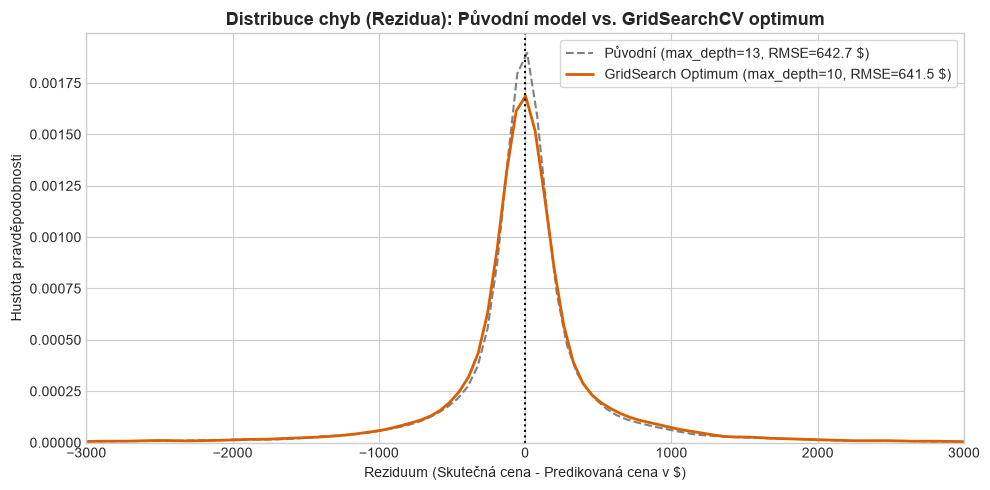

In [6]:
comparison_df = pd.DataFrame([
    {
        "Model": "1. Původní model (1. den)",
        "max_depth": 13,
        "criterion": "squared_error",
        "Train R²": f"{base_r2_train:.4f}",
        "Test R²": f"{base_r2_test:.4f}",
        "Test MAE": f"{base_mae_test:.2f} $",
        "Test RMSE": f"{base_rmse_test:.2f} $",
        "Generalization Gap (R²)": f"{base_r2_train - base_r2_test:.4f}"
    },
    {
        "Model": "2. Optimální model (GridSearchCV)",
        "max_depth": best_params['max_depth'],
        "criterion": best_params['criterion'],
        "Train R²": f"{optimal_result['r2_train']:.4f}",
        "Test R²": f"{optimal_result['r2_test']:.4f}",
        "Test MAE": f"{optimal_result['mae_test']:.2f} $",
        "Test RMSE": f"{optimal_result['rmse_test']:.2f} $",
        "Generalization Gap (R²)": f"{optimal_result['r2_train'] - optimal_result['r2_test']:.4f}"
    }
])
display(comparison_df)

# Zhodnocení
delta_rmse = base_rmse_test - optimal_result['rmse_test']
delta_gap = (base_r2_train - base_r2_test) - (optimal_result['r2_train'] - optimal_result['r2_test'])
pct_gap_reduction = delta_gap / (base_r2_train - base_r2_test) * 100

print(f"\n✅ ZLEPŠENÍ METRIK:")
print(f"1. Testovací RMSE pokleslo o {delta_rmse:+.2f} $ (přesnější predikce).")
print(f"2. Testovací R2 vzrostlo na {optimal_result['r2_test']:.4f}.")
print(f"3. Generalization gap (míra přeučení) klesla o {pct_gap_reduction:.1f} % (z {base_r2_train - base_r2_test:.4f} na {optimal_result['r2_train'] - optimal_result['r2_test']:.4f}).")

# Vizualizace chyb predikce
res_base = y_test - y_pred_base_test
res_opt = y_test - optimal_result['predictions']

plt.figure(figsize=(10, 5))
sns.kdeplot(res_base, label=f"Původní (max_depth=13, RMSE={base_rmse_test:.1f} $)", color="gray", linestyle="--")
sns.kdeplot(res_opt, label=f"GridSearch Optimum (max_depth={best_params['max_depth']}, RMSE={optimal_result['rmse_test']:.1f} $)", color="#d95f02", linewidth=2)
plt.axvline(0, color="black", linestyle=":")
plt.xlim(-3000, 3000)
plt.title("Distribuce chyb (Rezidua): Původní model vs. GridSearchCV optimum", fontsize=13, fontweight='bold')
plt.xlabel("Reziduum (Skutečná cena - Predikovaná cena v $)")
plt.ylabel("Hustota pravděpodobnosti")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()